In [2]:
# ✅ [셀 1] 환경 준비
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)


In [3]:
# ✅ [셀 2] "평균은 같은데 흩어짐이 다른" 두 데이터 만들기
# A: 흩어짐이 작음 / B: 흩어짐이 큼
A = np.random.normal(loc=50, scale=5, size=200)   # 평균 50, 표준편차 5
B = np.random.normal(loc=50, scale=15, size=200)  # 평균 50, 표준편차 15

A_mean, B_mean = np.mean(A), np.mean(B)
A_var,  B_var  = np.var(A),  np.var(B)            # 모분산(ddof=0)
A_std,  B_std  = np.std(A),  np.std(B)

A_mean, B_mean, A_var, B_var, A_std, B_std


(49.796145174139575,
 51.288022803483145,
 21.56086121700279,
 218.09376908036455,
 4.643367443677357,
 14.76799814058644)

In [4]:
# ✅ [셀 3] 표본분산/표본표준편차도 같이 비교 (ddof=1)
A_var_s = np.var(A, ddof=1)
B_var_s = np.var(B, ddof=1)
A_std_s = np.std(A, ddof=1)
B_std_s = np.std(B, ddof=1)

A_var_s, B_var_s, A_std_s, B_std_s


(21.669207253269136, 219.18971766870808, 4.655019576035007, 14.805057165330638)

In [5]:
# ✅ [셀 3] 표본분산/표본표준편차도 같이 비교 (ddof=1)
A_var_s = np.var(A, ddof=1)
B_var_s = np.var(B, ddof=1)
A_std_s = np.std(A, ddof=1)
B_std_s = np.std(B, ddof=1)

A_var_s, B_var_s, A_std_s, B_std_s


(21.669207253269136, 219.18971766870808, 4.655019576035007, 14.805057165330638)

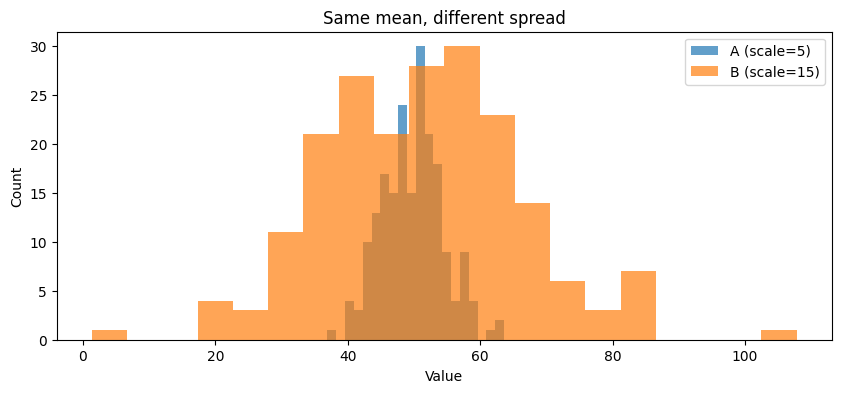

In [6]:
# ✅ [셀 5] 같은 평균, 다른 분산이 "모양"으로 어떻게 보이는지
plt.figure(figsize=(10,4))
plt.hist(A, bins=20, alpha=0.7, label="A (scale=5)")
plt.hist(B, bins=20, alpha=0.7, label="B (scale=15)")
plt.title("Same mean, different spread")
plt.xlabel("Value")
plt.ylabel("Count")
plt.legend()
plt.show()


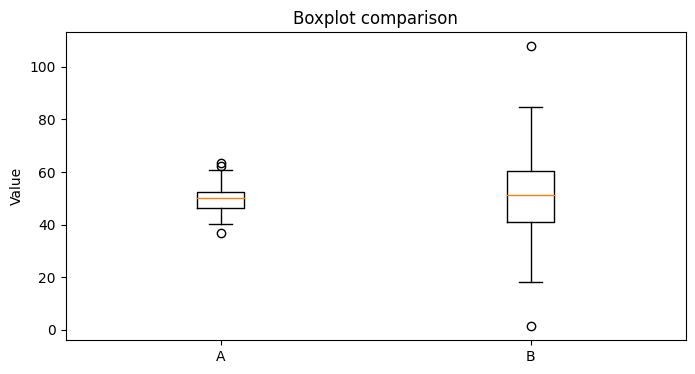

In [8]:
# ✅ [셀 6] 박스플롯으로도 비교 (분포 요약 그림)
plt.figure(figsize=(8,4))
plt.boxplot([A, B], labels=["A", "B"])
plt.title("Boxplot comparison")
plt.ylabel("Value")
plt.show()


In [9]:
# ✅ [셀 7] (선택) z-score 직관: '평균에서 몇 표준편차 떨어졌나'
# 예: 값 65는 A/B에서 얼마나 "특이한" 값인가?
x = 65
z_A = (x - np.mean(A)) / np.std(A, ddof=1)
z_B = (x - np.mean(B)) / np.std(B, ddof=1)

print(f"x={x}일 때, A의 z-score: {z_A:.2f}")
print(f"x={x}일 때, B의 z-score: {z_B:.2f}")
print("👉 같은 값이라도 표준편차가 큰 집단에서는 덜 특이하게 보입니다.")


x=65일 때, A의 z-score: 3.27
x=65일 때, B의 z-score: 0.93
👉 같은 값이라도 표준편차가 큰 집단에서는 덜 특이하게 보입니다.


In [10]:
# ✅ [셀 8] Pandas 불러오기
import pandas as pd


In [11]:
# ✅ [셀 9] DataFrame 만들기 (A, B를 컬럼으로 구성)
df = pd.DataFrame({
    "A": A,
    "B": B
})

df.head()


,A,B
0,52.483571,55.366810
1,49.308678,58.411768
2,53.238443,66.245769
3,57.615149,65.807031
4,48.829233,29.334959


In [12]:
# ✅ [셀 10] DataFrame의 기본 정보 확인
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       200 non-null    float64
 1   B       200 non-null    float64
dtypes: float64(2)
memory usage: 3.2 KB


In [13]:
# ✅ [셀 10] DataFrame의 기본 정보 확인
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       200 non-null    float64
 1   B       200 non-null    float64
dtypes: float64(2)
memory usage: 3.2 KB


In [14]:
# ✅ [셀 11] 기술통계 요약 (mean, std 포함)
df.describe()


,A,B
count,200.000000,200.000000
mean,49.796145,51.288023
std,4.655020,14.805057
min,36.901274,1.380990
25%,46.474362,40.912437
50%,49.979041,51.182590
75%,52.504262,60.308467
max,63.600846,107.790972


In [15]:
# ✅ [셀 12] 컬럼 단위로 평균/표준편차만 뽑아보기
summary = pd.DataFrame({
    "mean": df.mean(),
    "std_sample": df.std(ddof=1),
    "var_sample": df.var(ddof=1)
})
summary


,mean,std_sample,var_sample
A,49.796145,4.655020,21.669207
B,51.288023,14.805057,219.189718


In [16]:
# ✅ [셀 13] 결측치(NaN) 맛보기: 일부 값을 비워보면?
df_nan = df.copy()
df_nan.loc[np.random.choice(df_nan.index, size=10, replace=False), "A"] = np.nan

df_nan.isna().sum()


A    10
B     0
dtype: int64

In [17]:
# ✅ [셀 14] NaN이 있어도 describe는 계산을 "가능한 값" 기준으로 수행
df_nan.describe()


,A,B
count,190.000000,200.000000
mean,49.713038,51.288023
std,4.650897,14.805057
min,36.901274,1.380990
25%,46.273684,40.912437
50%,49.979041,51.182590
75%,52.545646,60.308467
max,62.316211,107.790972


In [18]:
# ✅ [셀 15] (중요) NaN이 있을 때 평균/표준편차 계산이 어떻게 되는지
print("A 평균 (NaN 포함):", df_nan["A"].mean())
print("A 표준편차 (NaN 포함):", df_nan["A"].std(ddof=1))


A 평균 (NaN 포함): 49.71303787390443
A 표준편차 (NaN 포함): 4.6508967359353175


In [19]:
# ✅ [셀 16] 해석 문장 자동 생성 예시
mean_A = df["A"].mean()
std_A  = df["A"].std(ddof=1)
mean_B = df["B"].mean()
std_B  = df["B"].std(ddof=1)

print(f"A의 평균은 {mean_A:.2f}이고, 표준편차는 {std_A:.2f}입니다.")
print(f"B의 평균은 {mean_B:.2f}이고, 표준편차는 {std_B:.2f}입니다.")

if std_B > std_A:
    print("따라서 B가 A보다 값의 변동성이 더 큰 집단으로 해석할 수 있습니다.")
else:
    print("따라서 A가 B보다 값의 변동성이 더 큰 집단으로 해석할 수 있습니다.")


A의 평균은 49.80이고, 표준편차는 4.66입니다.
B의 평균은 51.29이고, 표준편차는 14.81입니다.
따라서 B가 A보다 값의 변동성이 더 큰 집단으로 해석할 수 있습니다.
